In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = "/content/drive/MyDrive/praktikum_ml/praktikum10"

In [4]:
import pandas as pd

In [8]:
df= pd.read_csv(path + '/dataset/weather_classification_data.csv')

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [12]:
X = df.drop("Weather Type", axis=1)   # Fitur
y = df["Weather Type"]                # Label / target

In [13]:
# Identifikasi kolom kategorikal dn numerik
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

In [14]:
print("\nKolom Kategorikal:", cat_cols)
print("Kolom Numerik:", num_cols)


Kolom Kategorikal: ['Cloud Cover', 'Season', 'Location']
Kolom Numerik: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']


In [15]:
# reprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

In [17]:
X_processed = preprocessor.fit_transform(X)

In [18]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

In [19]:
print("\nUkuran Data Train:", X_train.shape)
print("Ukuran Data Test:", X_test.shape)


Ukuran Data Train: (10560, 18)
Ukuran Data Test: (2640, 18)


In [20]:
# Model KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [21]:
# prediksi
y_pred = knn.predict(X_test)

In [24]:
# evaluasi
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Cloudy       0.86      0.88      0.87       651
       Rainy       0.87      0.89      0.88       647
       Snowy       0.94      0.94      0.94       701
       Sunny       0.92      0.87      0.90       641

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



In [23]:
cm = confusion_matrix(y_test, y_pred)
print("\n===== CONFUSION MATRIX =====")
print(cm)


===== CONFUSION MATRIX =====
[[573  45  12  21]
 [ 37 579  18  13]
 [ 14  17 658  12]
 [ 42  27  15 557]]


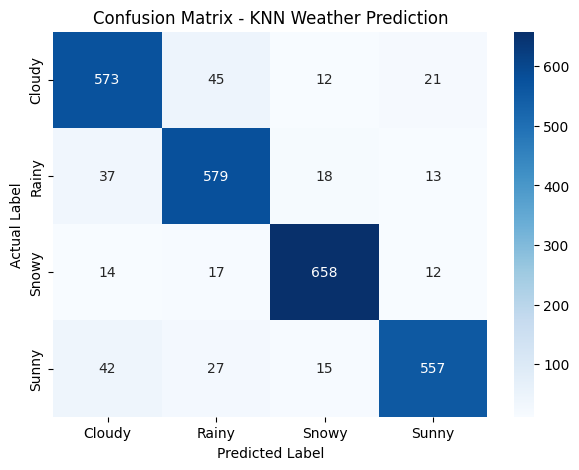

In [25]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_,
            yticklabels=knn.classes_)
plt.title("Confusion Matrix - KNN Weather Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [28]:
# Contoh Prediksi Data Baru
sample = pd.DataFrame({
    "Temperature": [20],
    "Humidity": [70],
    "Wind Speed": [5],
    "Precipitation (%)": [40],
    "Cloud Cover": ["overcast"],
    "Atmospheric Pressure": [1010],
    "UV Index": [3],
    "Season": ["Winter"],
    "Visibility (km)": [5],
    "Location": ["inland"]
})
sample_processed = preprocessor.transform(sample)
predicted_weather = knn.predict(sample_processed)

In [30]:
print("\nPrediksi Cuaca untuk Data Baru:", predicted_weather[0])


Prediksi Cuaca untuk Data Baru: Cloudy
